# **5. Splines de suavizamiento.**

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from pygam import LinearGAM, s

## 5.2 Cargar los datos.

In [2]:
Wage = load_data("Wage")
Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
age = Wage["age"]
y = Wage["wage"]

## 5.3 Preparar el predictor para pygam.

In [4]:
X_age = np.asarray(age).reshape(-1,1)
X_age.shape

(3000, 1)

## 5.4 Nuestro primer spline de suavizamiento.

In [5]:
gam = LinearGAM(s(0, lam = 0.6))
gam.fit(X_age, y)


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [6]:
age_grid = np.linspace(age.min(), age.max(), 500)
age_grid_matrix = age_grid.reshape(-1,1)
age_grid_matrix.shape

(500, 1)

In [7]:
pred = gam.predict(age_grid_matrix)
pred

array([ 60.15180613,  60.4703563 ,  60.79151396,  61.11559008,
        61.44289563,  61.7737416 ,  62.10843897,  62.44729871,
        62.79063181,  63.13874924,  63.49196199,  63.85058102,
        64.21491733,  64.58528188,  64.96198566,  65.34533965,
        65.73565482,  66.13324215,  66.53841263,  66.95147723,
        67.37274693,  67.80253271,  68.24114554,  68.68889642,
        69.14609631,  69.61305619,  70.09008705,  70.57749986,
        71.0756056 ,  71.58471525,  72.10509726,  72.63648878,
        73.1782658 ,  73.72979741,  74.29045269,  74.85960074,
        75.43661064,  76.02085149,  76.61169237,  77.20850237,
        77.81065059,  78.4175061 ,  79.02843801,  79.64281539,
        80.26000734,  80.87938295,  81.5003113 ,  82.12216149,
        82.7443026 ,  83.36610373,  83.98693395,  84.60616237,
        85.22315807,  85.83729014,  86.44792767,  87.05443974,
        87.65619545,  88.25256389,  88.84291414,  89.42661634,
        90.00312554,  90.57204298,  91.13298441,  91.68

## 5.6 Visualizar el spline.

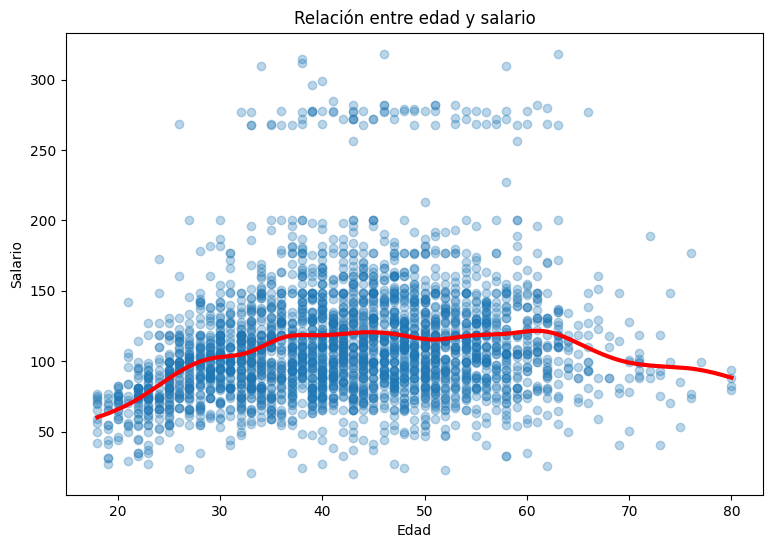

In [8]:
plt.figure(figsize=(9,6))

plt.scatter(age, y, alpha = 0.3)

plt.plot(age_grid, pred, linewidth = 3, color = "red")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Relación entre edad y salario")
plt.show()

## 5.7 Efecto del parámetro $\lambda$

In [9]:
lambdas = np.logspace(-2, 6, 5)
lambdas

array([1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06])

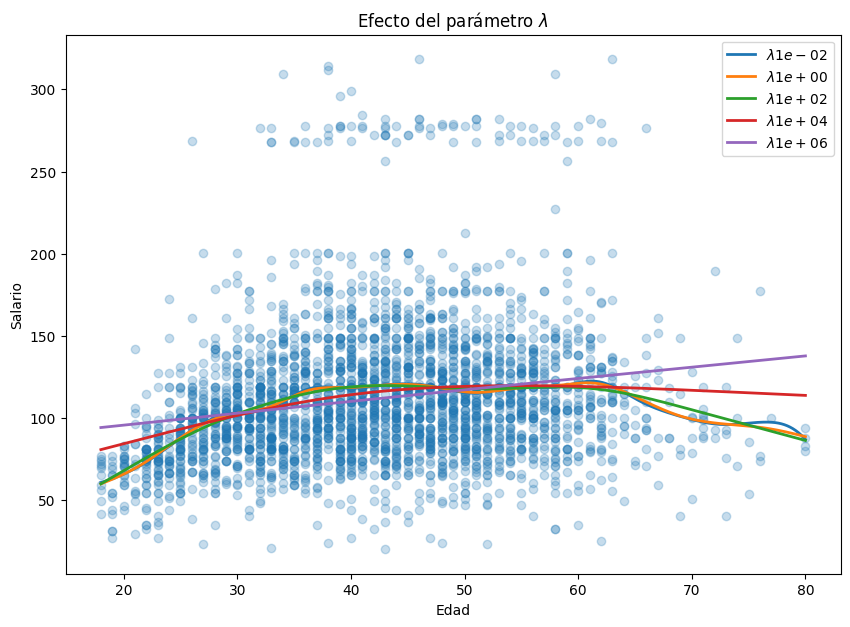

In [10]:
plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

for lam in lambdas:
    gam_lam = LinearGAM(s(0, lam = lam))
    gam_lam.fit(X_age, y)
    pred_lam = gam_lam.predict(age_grid_matrix)
    plt.plot(age_grid, pred_lam, linewidth = 2, label = fr"$\lambda{lam : .0e}$")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title(r"Efecto del parámetro $\lambda$")
plt.legend()
plt.show()

## 5.11 Búsqueda de $\lambda$.

In [11]:
lam_grid = np.logspace(-3, 5, 30)
lam_grid

array([1.00000000e-03, 1.88739182e-03, 3.56224789e-03, 6.72335754e-03,
       1.26896100e-02, 2.39502662e-02, 4.52035366e-02, 8.53167852e-02,
       1.61026203e-01, 3.03919538e-01, 5.73615251e-01, 1.08263673e+00,
       2.04335972e+00, 3.85662042e+00, 7.27895384e+00, 1.37382380e+01,
       2.59294380e+01, 4.89390092e+01, 9.23670857e+01, 1.74332882e+02,
       3.29034456e+02, 6.21016942e+02, 1.17210230e+03, 2.21221629e+03,
       4.17531894e+03, 7.88046282e+03, 1.48735211e+04, 2.80721620e+04,
       5.29831691e+04, 1.00000000e+05])

In [12]:
gam_opt = LinearGAM(s(0))

gam_opt.gridsearch(X_age, y, lam = lam_grid, progress = False)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [13]:
gam_opt.lam

[[np.float64(174.33288221999874)]]

## 5.12 Comparar un valor arbitrario con el valor seleccionado.

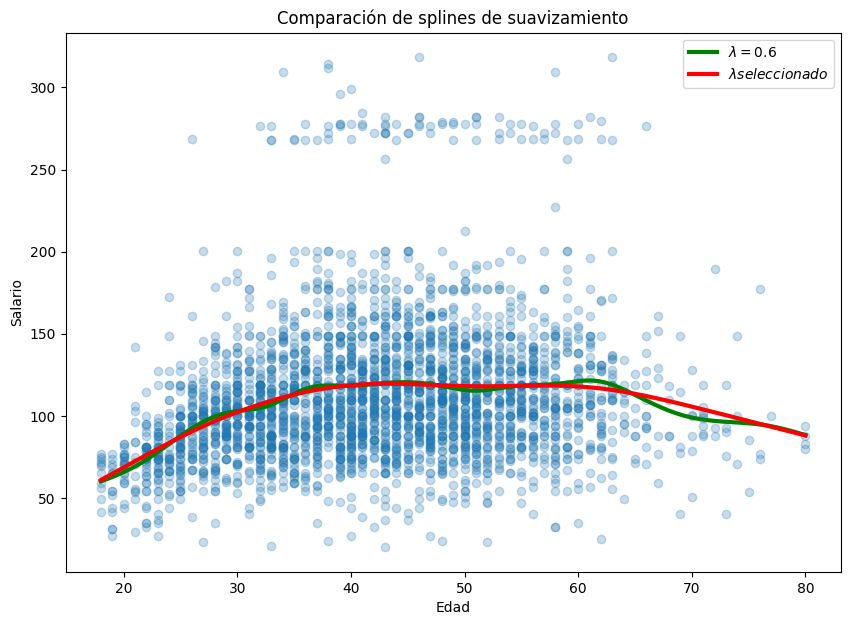

In [14]:
pred_default = gam.predict(age_grid_matrix)
pred_opt = gam_opt.predict(age_grid_matrix)

plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

plt.plot(age_grid, pred_default, linewidth = 3, color = "green", label = r"$\lambda = 0.6$")
plt.plot(age_grid, pred_opt, linewidth = 3, color = "red", label = r"$\lambda seleccionado$")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Comparación de splines de suavizamiento")
plt.legend()
plt.show()

## 5.13 Grados de libertad efectivos del modelo.

In [15]:
gam_opt.statistics_["edof"]

np.float64(6.061955860252573)

In [16]:
resultados = []

for lam in np.logspace(-2, 6, 9):
    modelo = LinearGAM(s(0, lam = lam)).fit(X_age,y)
    resultados.append({"lambda": lam, "df_efectivos":modelo.statistics_["edof"]})

df_lambda = pd.DataFrame(resultados)
df_lambda

,lambda,df_efectivos
0,0.01,18.747147
1,0.10,17.320972
2,1.00,14.408054
3,10.00,10.305159
4,100.00,6.752265
5,1000.00,4.299985
6,10000.00,2.793035
7,100000.00,2.132564
8,1000000.00,2.014363


In [17]:
df_lambda["lambda"]

0          0.01
1          0.10
2          1.00
3         10.00
4        100.00
5       1000.00
6      10000.00
7     100000.00
8    1000000.00
Name: lambda, dtype: float64

C:\Users\analu\AppData\Local\Temp\ipykernel_29488\4022567964.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


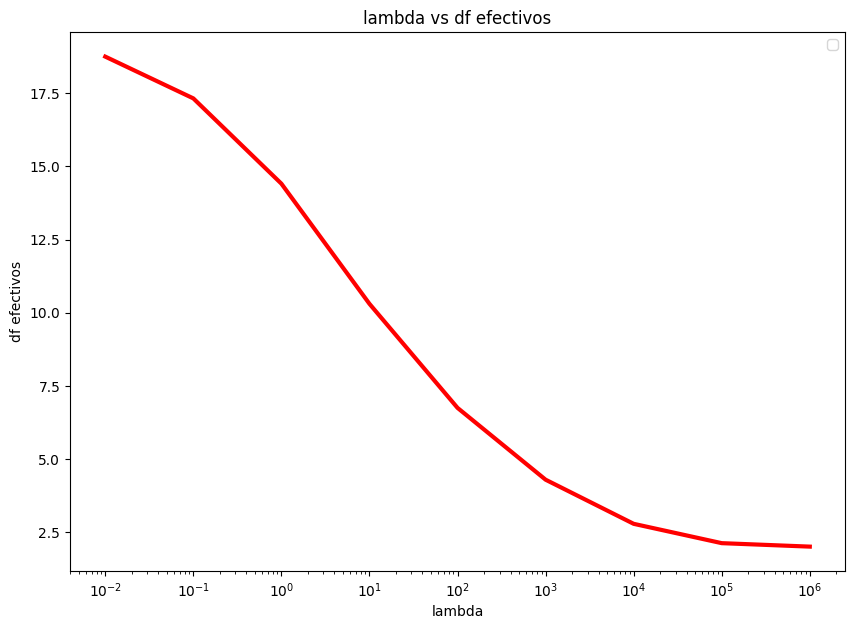

In [18]:
plt.figure(figsize=(10,7))

plt.plot(df_lambda["lambda"], df_lambda["df_efectivos"], linewidth = 3, color = "red")

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("df efectivos")
plt.title("lambda vs df efectivos")
plt.legend()
plt.show()

## 5.15 Comparación con una regresión lineal.

In [19]:
coef_lineal = np.polyfit(age, y, deg = 1)
pred_lineal = np.polyval(coef_lineal, age_grid)

In [20]:
gam_suave = LinearGAM(s(0, lam = 1e10))
gam_suave.fit(X_age, y)
pred_suave = gam_suave.predict(age_grid_matrix)

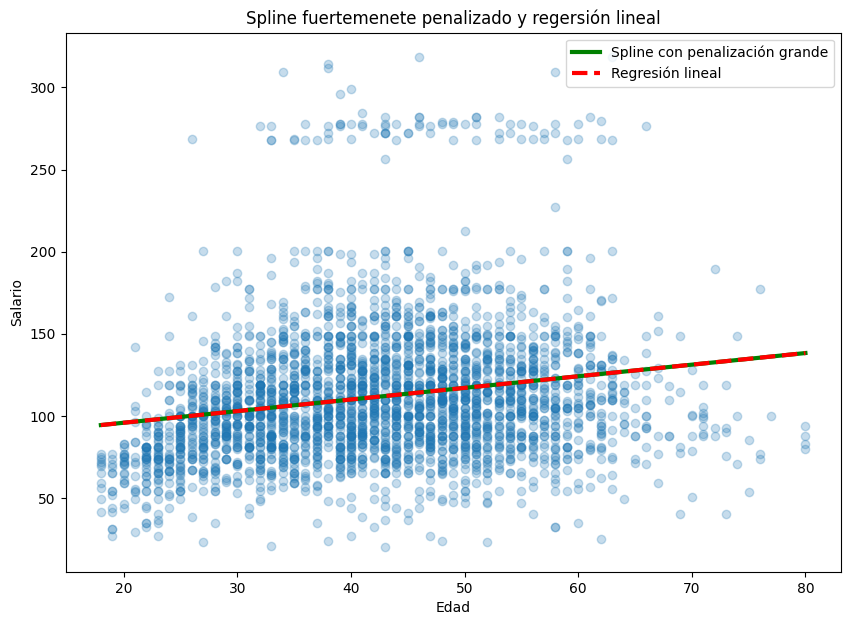

In [21]:
plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

plt.plot(age_grid, pred_suave, linewidth = 3, label = "Spline con penalización grande", color = "green")

plt.plot(age_grid, pred_lineal, linestyle = "--", linewidth = 3, color = "red", label = "Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline fuertemenete penalizado y regersión lineal")
plt.legend()
plt.show()

## EJERCICIOS

**5.17.1 Ejercicio 1. Efecto de $\lambda$**. Ajusta splines de suavizamiento utilizando los siguientes valores:

$$
\lambda = 10^{-4}, 10^{-2}, 1, 10^{2}, 10^{4}, 10^{8}
$$

Representa todos los ajustes en una misma gráfica.

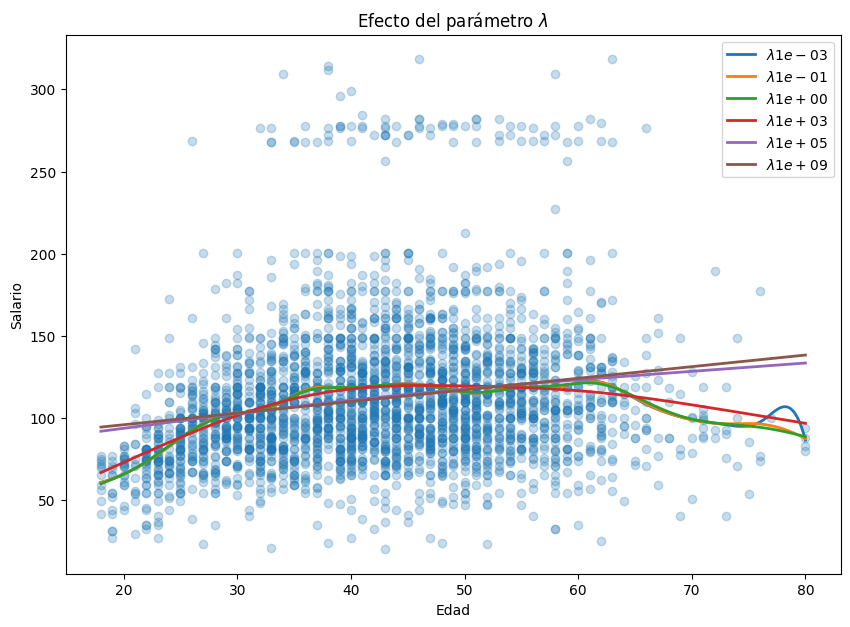

In [22]:
lambdas1 = [10e-4, 10e-2, 1, 10e2, 10e4, 10e8]

plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

for lam in lambdas1:
    gam_lam = LinearGAM(s(0, lam = lam))
    gam_lam.fit(X_age, y)
    pred_lam = gam_lam.predict(age_grid_matrix)
    plt.plot(age_grid, pred_lam, linewidth = 2, label = fr"$\lambda{lam : .0e}$")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title(r"Efecto del parámetro $\lambda$")
plt.legend()
plt.show()

Preguntas:
- ¿Qué ocurre con la curva conforme aumenta?

Se vuelve menos rígida.

- ¿Cuál de los modelos parece más flexible?

El de lambda igual a $10^{8}$
- ¿Cuál parece presentar mayor sesgo?

El de lambda igual a $10^{-4}$
- ¿Cuál podría presentar mayor varianza?

El de lambda igual a $10^{8}$

**5.17.2 Ejercicio 2. Grados de libertad efectivos.** Para cada uno de los valores de $\lambda$ del ejercicio anterior, obtén los grados de libertad efectivos mediante *modelo.statistics_["edof"]*.

Construye una tabla con las columnas $\lambda$ y Grados de libertad efectivos.



In [23]:
resultados2 = []
lambdas2 = [10e-4, 10e-2, 1, 10e2, 10e4, 10e8]

for lam in lambdas2:
    modelo = LinearGAM(s(0, lam = lam)).fit(X_age,y)
    resultados2.append({"lambda": lam, "df_efectivos":modelo.statistics_["edof"]})

df_lambda2 = pd.DataFrame(resultados2)
df_lambda2

,lambda,df_efectivos
0,1.000000e-03,19.411589
1,1.000000e-01,17.320972
2,1.000000e+00,14.408054
3,1.000000e+03,4.299985
4,1.000000e+05,2.132564
5,1.000000e+09,1.999812


Después representa gráficamente $df_{\lambda}$ contra $\lambda$. Utiliza escala logarítmica para el eje correspondiente a $\lambda$.

C:\Users\analu\AppData\Local\Temp\ipykernel_29488\1326559307.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


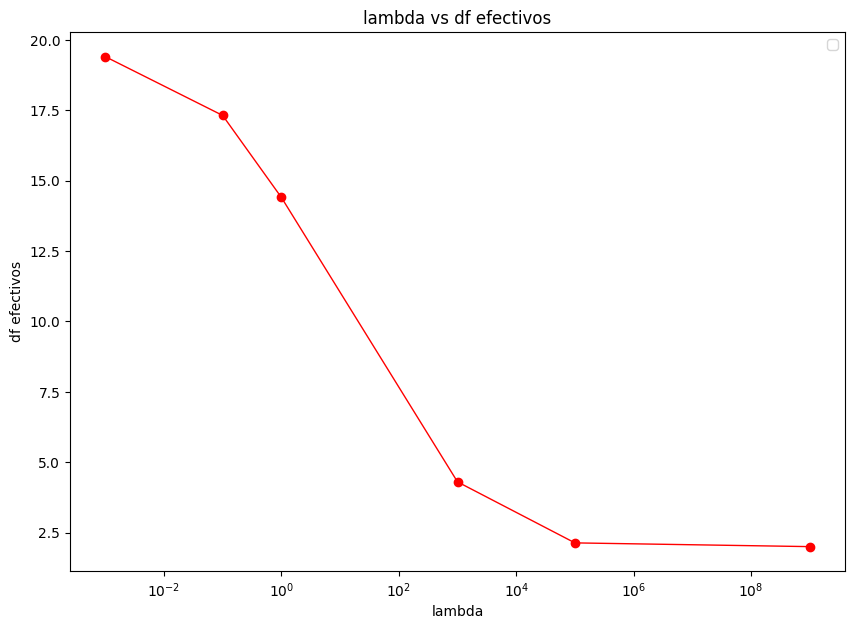

In [24]:
plt.figure(figsize=(10,7))

plt.plot(df_lambda2["lambda"], df_lambda2["df_efectivos"], linewidth = 1, color = "red", marker="o")

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("df efectivos")
plt.title("lambda vs df efectivos")
plt.legend()
plt.show()

Pregunta:
- ¿Los resultados coinciden con la relación teórica esperada?

Sí, dado que apreciamos como al aumentar lambda, baja el número de grados efectivos.

**5.17.3 Ejercicio 3. Selección de $\lambda$.** Utiliza $gridsearch()$ para seleccionar automáticamente un valor de $\lambda$.

Considera como candidatos

$$
10^{-4} \leq \lambda \leq 10^{6}.
$$

Después:

- reporta el valor seleccionado;

In [25]:
lam_grid3 = np.logspace(-4, 6, 30)

In [26]:
gam_opt3 = LinearGAM(s(0))

gam_opt3.gridsearch(X_age, y, lam = lam_grid3, progress = False)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [42]:
print(f"El valor seleccionado fue {gam_opt3.lam[0][0]:.2f}")

El valor seleccionado fue 161.03


- reporta sus grados de libertad efectivos;

In [45]:

print(f"El valor seleccionado fue {gam_opt3.statistics_["edof"]:.2f}")

El valor seleccionado fue 6.16


- grafica el spline resultante;
- compáralo con los ajustes obtenidos manualmente.

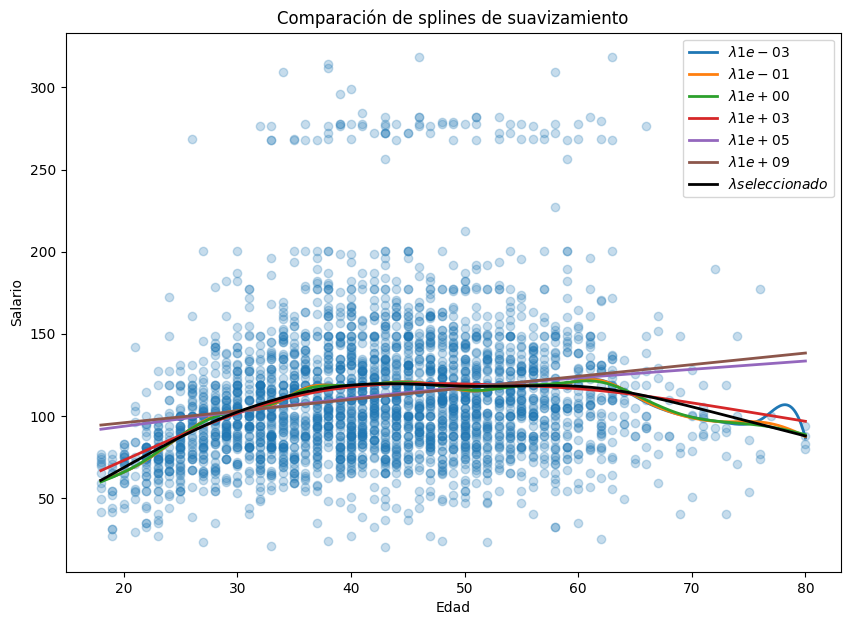

In [29]:
pred_opt3 = gam_opt3.predict(age_grid_matrix)

plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

for lam in lambdas1:
    gam_lam = LinearGAM(s(0, lam = lam))
    gam_lam.fit(X_age, y)
    pred_lam = gam_lam.predict(age_grid_matrix)
    plt.plot(age_grid, pred_lam, linewidth = 2, label = fr"$\lambda{lam : .0e}$")

plt.plot(age_grid, pred_opt3, linewidth = 2, color = "black", label = r"$\lambda seleccionado$")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Comparación de splines de suavizamiento")
plt.legend()
plt.show()

**Ejercicio 4. El límite lineal.** Ajusta splines utilizando valores cada vez mayores de $\lambda$.

Por ejemplo:

$$
10^{2}, 10^{4}, 10^{6}, 10^{8}, 10^{10}.
$$

Ajusta también una regresión lineal de $wage$ sobre $age$.

Representa todos los modelos.

In [30]:
lambdas4 = [10e2, 10e4, 10e6, 10e8, 10e10]

coef_lineal4 = np.polyfit(age, y, deg = 1)
pred_lineal4 = np.polyval(coef_lineal4, age_grid)

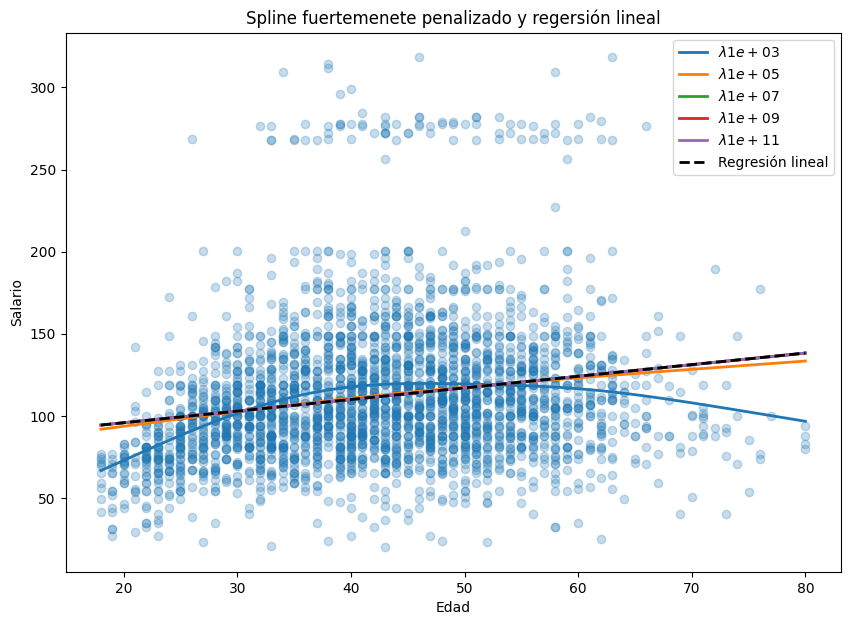

In [31]:
plt.figure(figsize=(10,7))

plt.scatter(age, y, alpha = 0.25)

for lam in lambdas4:
    gam_lam = LinearGAM(s(0, lam = lam))
    gam_lam.fit(X_age, y)
    pred_lam = gam_lam.predict(age_grid_matrix)
    plt.plot(age_grid, pred_lam, linewidth = 2, label = fr"$\lambda{lam : .0e}$")

plt.plot(age_grid, pred_lineal, linestyle = "--", linewidth = 2, color = "black", label = "Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline fuertemenete penalizado y regersión lineal")
plt.legend()
plt.show()

Pregunta:
- ¿Qué observas conforme $\lambda$ aumenta?

La recta empieza a ser menos flexible.

**5.17.5 Ejercicio 5. Interpretación.** Sin ejecutar código, responde:

- Si un spline tiene muchos grados de libertad efectivos, ¿esperas que $\lambda$ sea grande o pequeño?

Pequeño.
- Si $\lambda \longrightarrow \infty$, ¿qué tipo de función esperamos obtener?

Una función lineal.
- ¿Por qué no es conveniente seleccionar $\lambda$ únicamente observando qué modelo tiene el menor error de entrenamiento?

Porque podemos llegar al sobreajuste.
- ¿Cuál es la diferencia conceptual entre el número de parámetros del spline y sus grados de libertad efectivos?

El número de parámetros del spline son los coeficientes que describen la función, mientras que los grados de libertad efectivos miden la flexibilidad del modelo.
- ¿Qué relación existe entre $\lambda$, flexibilidad, sesgo y varianza?

Si lambda es muy grande, entonces hay menos flexibilidad y, por ende, el sesgo es mayor y la varianza pequeña. En cambio, si el lambda es muy pequeño, entonces hay más flexibilidad y, en consecuencia, el sesgo es pequeño, pero la varianza grande.

**5.17.6 Ejercicio 6. Otro predictor.** Repite el análisis utilizando year como predictor y wage como variable respuesta.

1) Construye un spline de suavizamiento.
2) Explora distintos valores de $\lambda$.
3) Obtén el valor seleccionado mediante gridsearch().
4) Obtén los grados de libertad efectivos.
5) Compara la relación year–wage con la relación age–wage.

In [32]:
year = Wage["year"]
X_year = np.asarray(year).reshape(-1,1)
gam6 = LinearGAM(s(0, lam = 0.6))
gam6.fit(X_year, y)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [33]:
year_grid = np.linspace(year.min(), year.max(), 500)
year_grid_matrix = year_grid.reshape(-1,1)

In [34]:
pred6 = gam6.predict(year_grid_matrix)

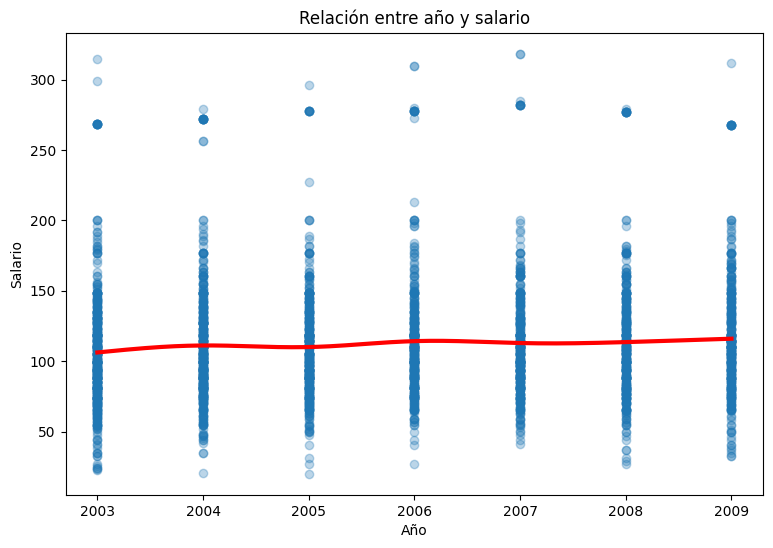

In [35]:
plt.figure(figsize=(9,6))

plt.scatter(year, y, alpha = 0.3)

plt.plot(year_grid, pred6, linewidth = 3, color = "red")

plt.xlabel("Año")
plt.ylabel("Salario")
plt.title("Relación entre año y salario")
plt.show()

In [36]:
lam_grid6 = np.logspace(-4, 6, 30)

gam_opt6 = LinearGAM(s(0))
gam_opt6.gridsearch(X_year, y, lam = lam_grid6, progress = False)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [44]:
print(f"El valor seleccionado fue {gam_opt6.lam[0][0]:.2f}")

El valor seleccionado fue 1000000.00


In [46]:
print(f"El valor seleccionado fue {gam_opt6.statistics_["edof"]:.2f}")

El valor seleccionado fue 2.05


**5.17.7 Ejercicio 7. Reflexión.** Supongamos que dos splines producen prácticamente el mismo desempeño predictivo:

- Modelo A: $df_\lambda = 15$;
- Modelo B: $df_\lambda = 5$.

¿Cuál preferirías?

Explica tu respuesta considerando:

- complejidad;
- interpretabilidad;
- riesgo de sobreajuste.

Prefiriría el modelo B porque su complejidad es menor, lo que facilita su interpretabilidad. Asimismo, los grados de libertad al ser bajos, evitamos caer en un sobreajuste.